In [220]:
import pandas as pd 
import numpy as np 
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import itertools

df_data = pd.read_csv('/Users/r1/Downloads/golden_mine.csv')

df = df_data.copy()
display(df.isna().sum())

Payments    0
Costs       0
Profit      0
Age         0
Gender      0
AgeGroup    0
dtype: int64

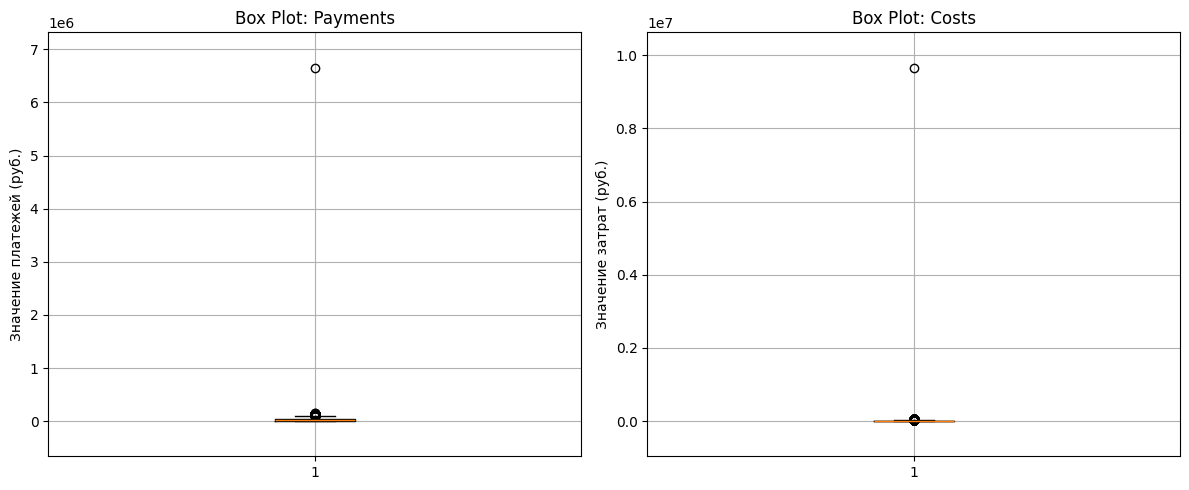

Минимальное значение Payments: 3750
Минимальное значение Costs: 3500


In [221]:
#Визуализация выбросов 

#Построим box plot для визуализации выбросов
plt.figure(figsize=(12, 5))

#Box plot для Payments
plt.subplot(1, 2, 1)
plt.boxplot(df['Payments'], whis=2)
plt.title('Box Plot: Payments')
plt.ylabel('Значение платежей (руб.)')
plt.grid(True)

#Box plot для Costs
plt.subplot(1, 2, 2)
plt.boxplot(df['Costs'], whis=2)
plt.title('Box Plot: Costs')
plt.ylabel('Значение затрат (руб.)')
plt.grid(True)

#Отступы для выделения выбросов
plt.subplot(1, 2, 1)
plt.margins(y=0.1)
plt.subplot(1, 2, 2)
plt.margins(y=0.1)

plt.tight_layout()
plt.show()

#Проверим min для каждого столбца, чтобы убедиться в отсутствии отрицательных значений
print("Минимальное значение Payments:", df_cleaned['Payments'].min())
print("Минимальное значение Costs:", df_cleaned['Costs'].min())

In [222]:
df = df.drop(index = 8322)
df = df.drop(index = 2759)
df.head(10)

,Payments,Costs,Profit,Age,Gender,AgeGroup
0,9400,8100,1300,19,male,18-24
1,26600,13900,12700,29,male,25-39
2,9750,6750,3000,20,male,18-24
3,29700,11200,18500,18,female,18-24
4,49700,10450,39250,21,female,18-24
5,14300,7500,6800,18,male,18-24
6,30300,11400,18900,18,female,18-24
7,53100,17800,35300,21,female,18-24
8,10300,7700,2600,18,male,18-24
9,111400,35650,75750,21,male,18-24


In [223]:
#Для слайда «Мужчины 18–24 лет» и «Женщины 18–24 лет»
cost = 15000
alpha = 0.05
n = 10_000
np.random.seed(42)

men = df[(df.Gender == 'male') & (df.Age.between(18, 24))]['Profit'].values
women = df[(df.Gender == 'female') & (df.Age.between(18, 24))]['Profit'].values

mean_men = men.mean()
mean_women = women.mean()
mean_diff = mean_men - mean_women

diff = np.array([
    np.random.choice(men, len(men), True).mean()
    - np.random.choice(women, len(women), True).mean()
    for _ in range(n)
])

ci_low, ci_high = np.percentile(diff, [2.5, 97.5])
p_diff = np.mean(np.abs(diff) >= abs(mean_diff))

# тест прибыль > cost
p_men = stats.ttest_1samp(men, cost, alternative='greater').pvalue
p_women = stats.ttest_1samp(women, cost, alternative='greater').pvalue

# итоговый вывод
print(f"""
Средняя прибыль:
Мужчины 18–24: {mean_men:,.0f} 
Женщины 18–24: {mean_women:,.0f} 

Разница средних: {abs(mean_diff):,.0f} 
95% ДИ: [{ci_low:,.0f}  ; {ci_high:,.0f} ]
p-value разницы: {p_diff:.4f}

p-value:
Мужчины 18–24: {p_men:.4f}
Женщины 18–24: {p_women:.4f}
""") 



Средняя прибыль:
Мужчины 18–24: 13,156 
Женщины 18–24: 26,278 

Разница средних: 13,123 
95% ДИ: [-14,063  ; -12,165 ]
p-value разницы: 0.5049

p-value:
Мужчины 18–24: 1.0000
Женщины 18–24: 0.0000



In [224]:
#для 3 слайда
cost = 15000

w18_21 = df[(df.Gender == 'female') & (df.Age.between(18, 21))]['Profit']
w22_24 = df[(df.Gender == 'female') & (df.Age.between(22, 24))]['Profit']

mean_18_21 = w18_21.mean()
mean_22_24 = w22_24.mean()

p_diff = stats.ttest_ind(w18_21, w22_24, equal_var=False).pvalue
p_18_21 = stats.ttest_1samp(w18_21, cost, alternative='greater').pvalue
p_22_24 = stats.ttest_1samp(w22_24, cost, alternative='greater').pvalue

print(f"""
Женщины 18–21 лет:
Средняя прибыль: {mean_18_21:,.0f} 
p-value: {p_18_21:.4f}

Женщины 22–24 лет:
Средняя прибыль: {mean_22_24:,.0f} 
p-value: {p_22_24:.4f}

Сравнение подкатегорий:
p-value разницы средних: {p_diff:.4f}
""")


Женщины 18–21 лет:
Средняя прибыль: 25,717 
p-value: 0.0000

Женщины 22–24 лет:
Средняя прибыль: 29,891 
p-value: 0.0000

Сравнение подкатегорий:
p-value разницы средних: 0.0000



In [225]:
# Для 4 слайда

women = df[(df.Gender == 'female') & (df.Age.between(18, 24))]

ages = sorted(women.Age.unique())

# все попарные сравнения
results = []

for age1, age2 in itertools.combinations(ages, 2):
    group1 = women[women.Age == age1]['Profit']
    group2 = women[women.Age == age2]['Profit']

    p_value = stats.ttest_ind(group1, group2, equal_var=False).pvalue.round(6)
    results.append((age1, age2, p_value))

results_df = pd.DataFrame(
    results, columns=['age_1', 'age_2', 'p_value']
)

results_df

,age_1,age_2,p_value
0,18,19,0.409305
1,18,20,0.650442
2,18,21,0.000000
3,18,22,0.000000
4,18,23,0.000000
5,18,24,0.000000
6,19,20,0.845029
7,19,21,0.000000
8,19,22,0.000000
9,19,23,0.000001


In [226]:
# Для 5 слайда

women = df[(df.Gender == 'male') & (df.Age.between(18, 24))]

ages = sorted(women.Age.unique())

# все попарные сравнения
results = []

for age1, age2 in itertools.combinations(ages, 2):
    group1 = women[women.Age == age1]['Profit']
    group2 = women[women.Age == age2]['Profit']

    p_value = stats.ttest_ind(group1, group2, equal_var=False).pvalue.round(6)
    results.append((age1, age2, p_value))

results_df = pd.DataFrame(
    results, columns=['age_1', 'age_2', 'p_value']
)

results_df

,age_1,age_2,p_value
0,18,19,0.538530
1,18,20,0.088284
2,18,21,0.000000
3,18,22,0.000000
4,18,23,0.000000
5,18,24,0.000000
6,19,20,0.280503
7,19,21,0.000000
8,19,22,0.000000
9,19,23,0.000000


In [ ]:
#Для 6-7 слайда

# средняя прибыль по полу и возрасту
gold_candidates = (
    df
    .groupby(['Gender', 'Age'])['Profit']
    .agg(['mean', 'count'])
    .reset_index()
)

# оставляем только категории с достаточным числом наблюдений
gold_candidates = gold_candidates[gold_candidates['count'] >= 30]
gold_candidates.sort_values('mean', ascending=False).head(5)


,Gender,Age,mean,count
38,male,23,80548.235294,85
37,male,22,80067.000000,100
36,male,21,78856.543624,298
39,male,24,78583.695652,46
18,female,23,32582.727273,55
